In [3]:
from hattmapper import HATTMapper, HATTNaiveMapper
from qiskit_nature.second_q.operators import FermionicOp
from collections import defaultdict
import time
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

plt.style.use("classic")
plt.rc("font", size=28, family="serif")

FH_time = """2;without;0.014502286911010742;0.022063732147216797
3;without;0.03156304359436035;0.042731523513793945
4;without;0.06342601776123047;0.480449914932251
5;without;0.11750006675720215;1.8133516311645508
6;without;0.19956541061401367;24.984264612197876
7;without;0.31441593170166016;415.84082317352295
8;without;0.4733719825744629;12029.315706014633"""

FH_time = [float(line.strip().split(";")[-1]) for line in FH_time.splitlines()]

MAXMODES = 20
MINMODES = 2

RESULT = defaultdict(list)


class Stopwatch:
    def __init__(self, name: str) -> None:
        self.name = name

    def __enter__(self):
        self.start_time = time.time()
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        self.end_time = time.time()
        self.elapsed_time = self.end_time - self.start_time

        RESULT[self.name].append(self.elapsed_time)

## Figure 12

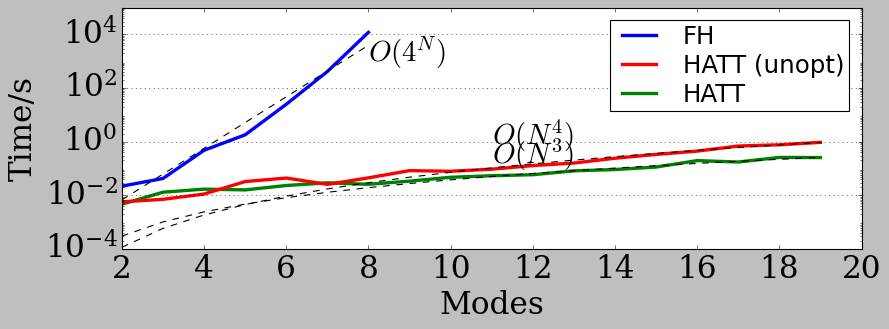

In [12]:
RESULT.clear()

for modes in range(2, MAXMODES):
    def to_acop(m: int, modes: int):
        if m % 2 == 0:
            j = m // 2
            return FermionicOp({f"+_{j}": 1.0, f"-_{j}": 1.0}, num_spin_orbitals=modes)
        else:
            j = (m - 1) // 2
            return FermionicOp(
                {f"+_{j}": 1.0j, f"-_{j}": -1.0j}, num_spin_orbitals=modes
            )

    hamiltonian = FermionicOp({}, num_spin_orbitals=modes)
    for i in range(modes):
        hamiltonian += to_acop(i, modes)

    with Stopwatch("naive"):
        HATTNaiveMapper(hamiltonian)

    with Stopwatch("optimized"):
        HATTMapper(hamiltonian)

plt.figure(figsize=(11, 4), layout="constrained")
plt.plot(range(2, 9), FH_time, linewidth=3, label="FH")
regs = linregress(np.arange(2, 9), np.log2(np.array(FH_time)))
K = 2**regs.slope
plt.plot(
    range(2, 9),
    (K ** np.arange(2, 9)) * (2**regs.intercept),
    linewidth=1,
    color="black",
    linestyle="--",
)
plt.text(8, 1000, "$O(4^N)$", fontsize=26)

plt.plot(range(2, MAXMODES), RESULT["optimized"], linewidth=3, label="HATT")
regs = linregress(np.arange(2, MAXMODES) ** 3, np.array(RESULT["optimized"]))
plt.plot(
    range(2, MAXMODES),
    (np.arange(2, MAXMODES) ** 3) * regs.slope,
    linewidth=1,
    color="black",
    linestyle="--",
)
plt.text(11, RESULT["optimized"][-1] - 0.105, "$O(N^3)$", fontsize=26)

plt.plot(range(2, MAXMODES), RESULT["naive"], linewidth=3, label="HATT (unopt)")
regs = linregress(np.arange(2, MAXMODES) ** 4, np.array(RESULT["naive"]))
plt.plot(
    range(2, MAXMODES),
    (np.arange(2, MAXMODES) ** 4) * regs.slope,
    linewidth=1,
    color="black",
    linestyle="--",
)
plt.text(11, RESULT["naive"][-1] - 0.18, "$O(N^4)$", fontsize=26)

handles, labels = plt.gca().get_legend_handles_labels()
order = [0, 2, 1]
plt.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    prop={"family": "sans serif", "size": 22},
    labelspacing=0.2,
    borderpad=0.2,
)
plt.yscale("log")
plt.yticks([10e-5, 10e-3, 10e-1, 10e1, 10e3])
plt.xlabel("Modes")
plt.ylabel("Time/s")
plt.grid(which="major", axis="y")
plt.show()